In [2]:
import numpy as np
import matplotlib.pyplot as plt
import codecs, re, os
import warnings
warnings.filterwarnings('ignore')

# Stop words et stemming 
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Classifieurs
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

# Post-traitement
from scipy.ndimage import gaussian_filter1d



# Données reconnaissance du locuteur (Chirac/Mitterrand)

In [3]:
# Chargement des données:
def load_pres(fname):
    alltxts = []
    alllabs = []
    s=codecs.open(fname, 'r','utf-8') # pour régler le codage
    while True:
        txt = s.readline()
        if(len(txt))<5:
            break
        #
        lab = re.sub(r"<[0-9]*:[0-9]*:(.)>.*","\\1",txt)
        txt = re.sub(r"<[0-9]*:[0-9]*:.>(.*)","\\1",txt)
        if lab.count('M') >0:
            alllabs.append(-1)
        else:
            alllabs.append(1)
        alltxts.append(txt)
    return alltxts,alllabs

def load_pres_test(fname):
    """Charge le fichier de test président (sans labels connus)."""
    alltxts = []
    s = codecs.open(fname, 'r', 'utf-8')
    while True:
        txt = s.readline()
        if len(txt) < 2:
            break
        txt = re.sub(r"<[0-9]*:[0-9]*:.>", "", txt).strip()
        if len(txt) > 1:
            alltxts.append(txt)
    return alltxts

In [4]:
fname = "./datasets/AFDpresidentutf8/corpus.tache1.learn.utf8"
alltxts, alllabs = load_pres(fname)

fname_test_pres = "./datasets/AFDpresidentutf8/corpus.tache1.test.utf8"
txts_test_pres = load_pres_test(fname_test_pres)

In [5]:
print(len(alltxts),len(alllabs))
print(f"Documents test Président : {len(txts_test_pres)}")
print(alltxts[0])
print(alllabs[0])
print(alltxts[-1])
print(alllabs[-1])

57413 57413
Documents test Président : 27162
 Quand je dis chers amis, il ne s'agit pas là d'une formule diplomatique, mais de l'expression de ce que je ressens.

1
 Je compte sur vous.

1


# Données classification de sentiments (films)

In [6]:
def load_movies(path2data): # 1 classe par répertoire
    alltxts = [] # init vide
    labs = []
    cpt = 0
    for cl in sorted([d for d in os.listdir(path2data) if not d.startswith('.') and os.path.isdir(path2data + d)]):
        for f in os.listdir(path2data+cl):
            if f.startswith('.'): continue
            txt = open(path2data+cl+'/'+f, encoding='latin-1').read()
            alltxts.append(txt)
            labs.append(cpt)
        cpt+=1 # chg répertoire = chg classe
    return alltxts,labs

def load_movies_test(fname):
    """Charge le fichier de test films (une critique par ligne)."""
    alltxts = []
    with open(fname, encoding='latin-1') as f:
        for line in f:
            line = line.strip()
            if len(line) > 1:
                alltxts.append(line)
    return alltxts

In [7]:
path = "./datasets/movies/"
alltxts_movies, alllabs_movies = load_movies(path)

fname_test_movies = "./datasets/movies/testSentiment.txt"
txts_test_movies = load_movies_test(fname_test_movies)

In [8]:
print(len(alltxts_movies),len(alllabs_movies))
print(f"Documents test Films : {len(txts_test_movies)}")
print(alltxts_movies[0][:100])
print(alllabs_movies[0])
print(alltxts_movies[-1][:100])
print(alllabs_movies[-1])

2000 2000
Documents test Films : 25000
bad . bad . 
bad . 
that one word seems to pretty much sums up beyond the valley of the dolls . 
if 
0
capsule : the director of cure brings a weird and very complex concept to the screen . 
one viewing 
1


# A) Transformation paramétrique du texte (pre-traitements)

Vous devez tester, par exemple, les cas suivants:
- transformation en minuscule ou pas
- suppression de la ponctuation
- transformation des mots entièrement en majuscule en marqueurs spécifiques
- suppression des chiffres ou pas
- conservation d'une partie du texte seulement (seulement la première ligne = titre, seulement la dernière ligne = résumé, ...)
- stemming
- ...


Vérifier systématiquement sur un exemple ou deux le bon fonctionnement des méthodes sur deux documents (au moins un de chaque classe).

In [9]:
# A) PRÉTRAITEMENTS 
# J'ai choisi d'appliquer 4 étapes de prétraitement :
# 1) Minuscules : "France" et "france" sont le même mot
# 2) Suppression ponctuation : les virgules/points n'apportent rien
# 3) Stop words : je retire les mots trop fréquents qui ne discriminent pas ("le", "de", "the"...)
# 4) Stemming Snowball : je réduis les mots à leur radical ("diplomatique" → "diplomat")
#    pour regrouper les formes d'un même mot ensemble
# J'utilise deux pipelines différents : un français pour les discours, un anglais pour les films

# Deux stemmers : Snowball français (Président) et anglais (Films)
stemmer_fr = SnowballStemmer('french')
stemmer_en = SnowballStemmer('english')
stop_fr    = set(stopwords.words('french'))
stop_en    = set(stopwords.words('english'))

def preprocess_fr(text, lowercase=True, remove_punct=True,
                  remove_stopwords=True, stem=True):
    """Pipeline de prétraitement pour les discours présidentiels (français)."""
    if lowercase:
        text = text.lower()
    if remove_punct:
        text = re.sub(r"[^a-zàâçéèêëîïôûùüÿœæ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_fr and len(t) > 2]
    if stem:
        tokens = [stemmer_fr.stem(t) for t in tokens]
    return " ".join(tokens)

def preprocess_en(text, lowercase=True, remove_punct=True,
                  remove_stopwords=True, stem=True):
    """Pipeline de prétraitement pour les critiques de films (anglais)."""
    if lowercase:
        text = text.lower()
    if remove_punct:
        text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_en and len(t) > 2]
    if stem:
        tokens = [stemmer_en.stem(t) for t in tokens]
    return " ".join(tokens)

# Vérification sur un exemple de chaque corpus 
print("=== Tâche Président (français) ===")
print(f"Avant : {alltxts[0][:150]}")
print(f"Après : {preprocess_fr(alltxts[0])[:150]}")

print("\n=== Tâche Films (anglais) ===")
print(f"Avant : {alltxts_movies[0][:150]}")
print(f"Après : {preprocess_en(alltxts_movies[0])[:150]}")

# Application à tous les documents (train + test)
txts_pres_pp      = [preprocess_fr(t) for t in alltxts]
txts_movies_pp    = [preprocess_en(t) for t in alltxts_movies]
txts_test_pres_pp = [preprocess_fr(t) for t in txts_test_pres]
txts_test_mov_pp  = [preprocess_en(t) for t in txts_test_movies]

print("\nPrétraitement appliqué à tous les documents train et test.")

=== Tâche Président (français) ===
Avant :  Quand je dis chers amis, il ne s'agit pas là d'une formule diplomatique, mais de l'expression de ce que je ressens.

Après : quand dis cher amis agit formul diplomat express ressen

=== Tâche Films (anglais) ===
Avant : bad . bad . 
bad . 
that one word seems to pretty much sums up beyond the valley of the dolls . 
if that summary isn't enough for you , how about t&a 
Après : bad bad bad one word seem pretti much sum beyond valley doll summari enough still got point director russ meyer predilect cast attract larg breast wom

Prétraitement appliqué à tous les documents train et test.


# B) Extraction du vocabulaire (BoW)

- **Exploration préliminaire des jeux de données**
    - Quelle est la taille d'origine du vocabulaire?
    - Que reste-t-il si on ne garde que les 100 mots les plus fréquents? [word cloud]
    - Quels sont les 100 mots dont la fréquence documentaire est la plus grande? [word cloud]
    - Quels sont les 100 mots les plus discriminants au sens de odds ratio? [word cloud]
    - Quelle est la distribution d'apparition des mots (Zipf)
    - Quels sont les 100 bigrammes/trigrammes les plus fréquents?

- **Variantes de BoW**
    - TF-IDF
    - Réduire la taille du vocabulaire (min_df, max_df, max_features)
    - BoW binaire
    - Bi-grams, tri-grams
    - **Quelles performances attendre ? Quels sont les avantages et les inconvénients des ces variantes?**

Taille vocabulaire Président : 12967 mots uniques
Taille vocabulaire Films     : 24596 mots uniques


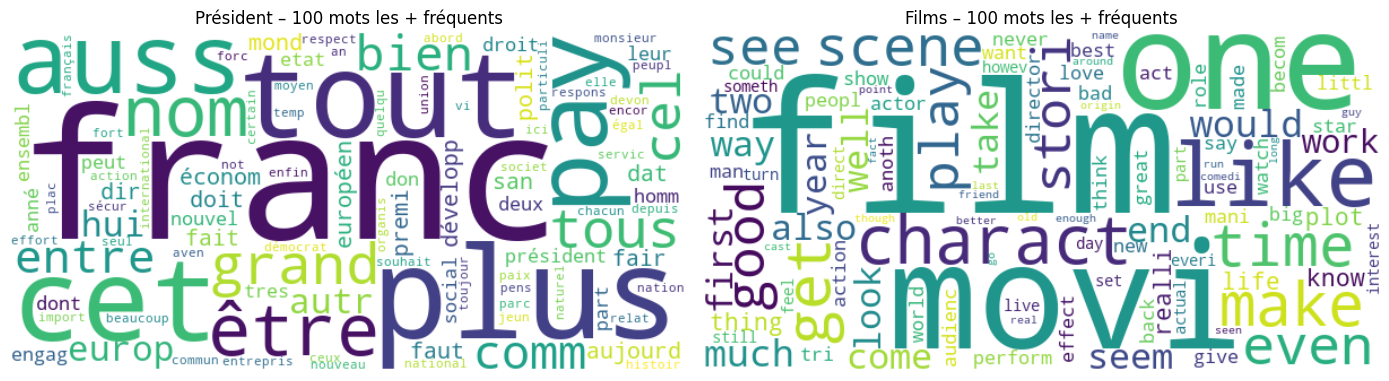

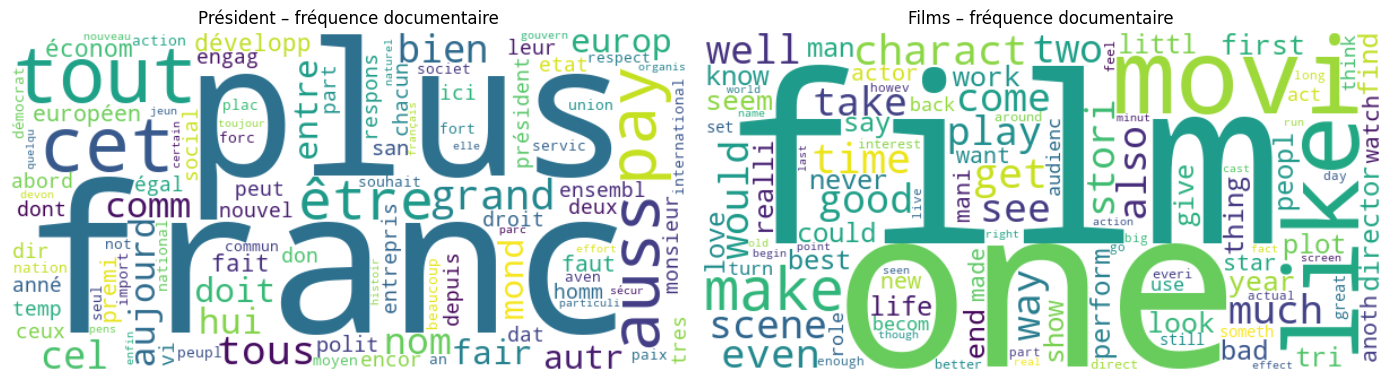

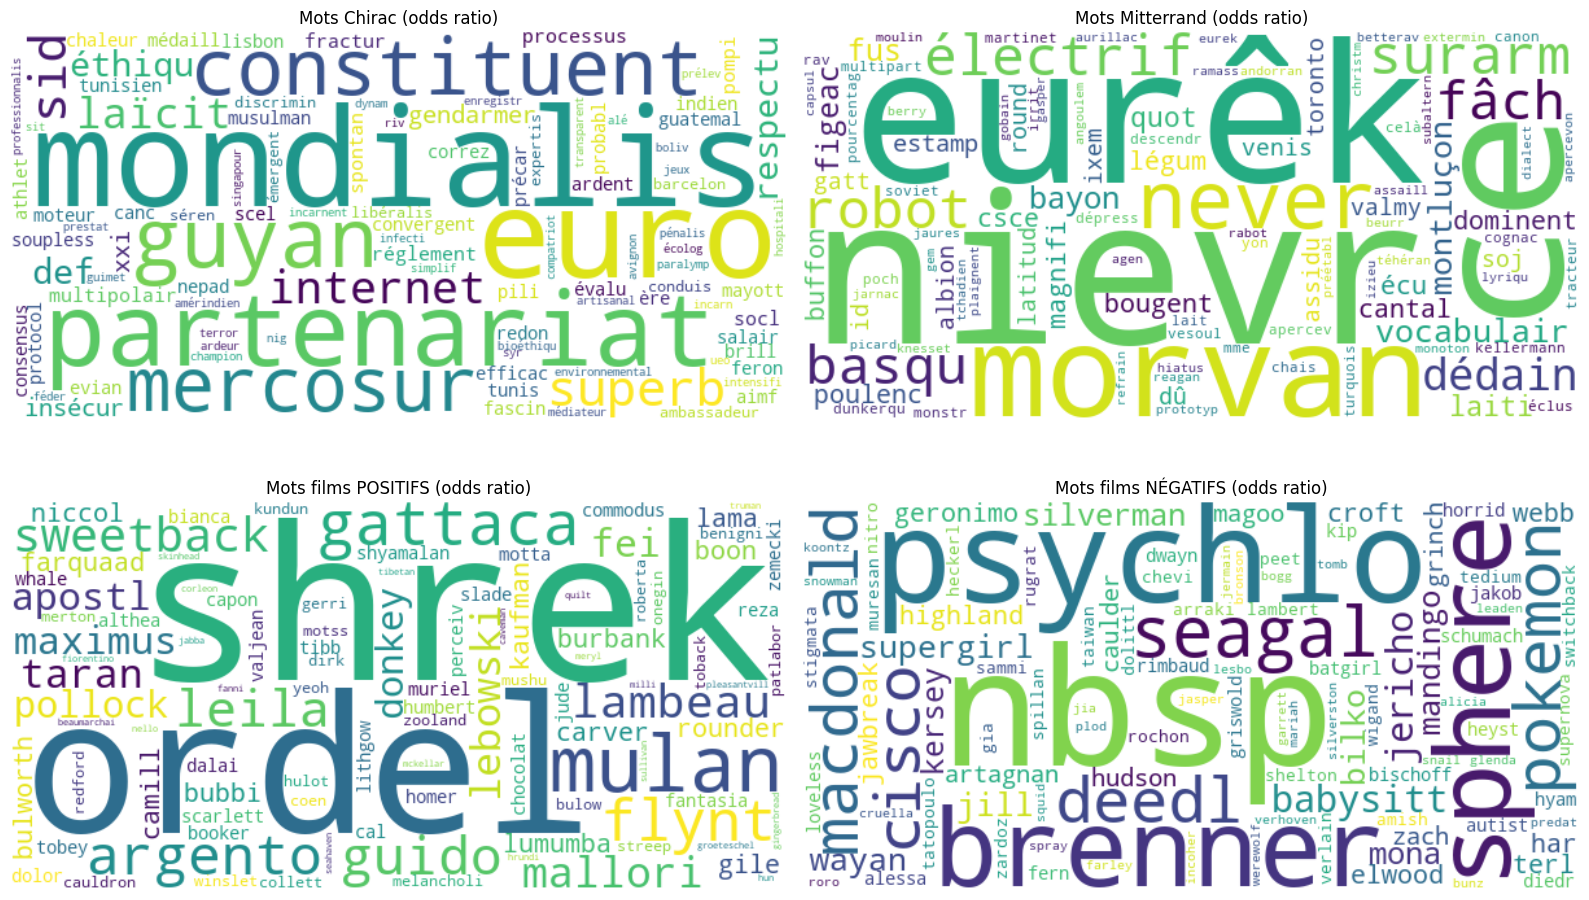

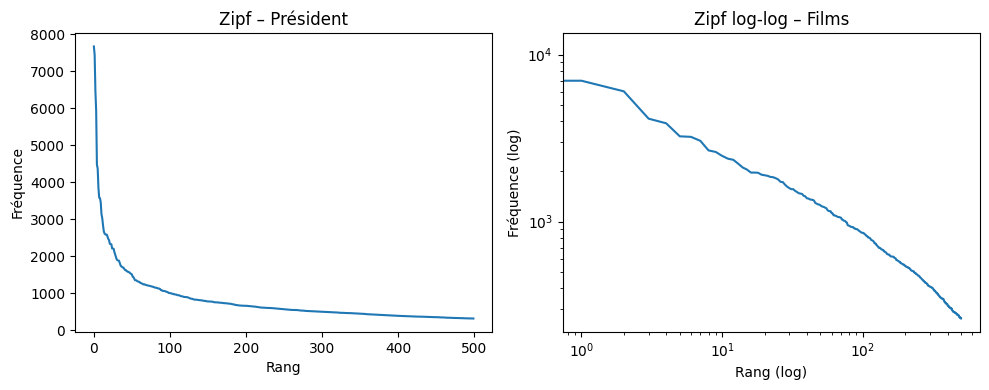


=== Président – Top 10 bigrammes ===
[('aujourd hui', np.int64(2581)), ('monsieur président', np.int64(923)), ('doit être', np.int64(816)), ('union européen', np.int64(664)), ('mesdam messieur', np.int64(611)), ('bien sûr', np.int64(496)), ('peut être', np.int64(480)), ('tout heur', np.int64(394)), ('lutt contr', np.int64(383)), ('plus grand', np.int64(372))]
=== Président – Top 10 trigrammes ===
[('entre deux pay', np.int64(162)), ('tout cel tous', np.int64(117)), ('cel tous ceux', np.int64(116)), ('chacun chacun entre', np.int64(107)), ('san aucun dout', np.int64(95)), ('aller plus loin', np.int64(88)), ('chef etat gouvern', np.int64(88)), ('monsieur premi ministr', np.int64(82)), ('évoqu tout heur', np.int64(78)), ('nom nom nom', np.int64(77))]

=== Films – Top 10 bigrammes ===
[('special effect', np.int64(401)), ('look like', np.int64(317)), ('new york', np.int64(250)), ('year old', np.int64(239)), ('even though', np.int64(222)), ('seem like', np.int64(197)), ('high school', np.in

In [10]:
#  B) VOCABULAIRE & VARIANTES BOW 
from collections import Counter
from wordcloud import WordCloud

# La loi de Zipf dit que quelques mots sont très fréquents et la majorité est rare.
# Je vérifie ça sur mes deux corpus ,si la courbe log-log est linéaire, la loi est vérifiée.
# Ça justifie d'utiliser TF-IDF : il faut downweighter les mots trop fréquents.


# 1. TAILLE DU VOCABULAIRE

all_words_pres = " ".join(txts_pres_pp).split()
freq_pres      = Counter(all_words_pres)
all_words_mov  = " ".join(txts_movies_pp).split()
freq_mov       = Counter(all_words_mov)

print(f"Taille vocabulaire Président : {len(freq_pres)} mots uniques")
print(f"Taille vocabulaire Films     : {len(freq_mov)} mots uniques")


# 2. WORD CLOUD – 100 mots les plus fréquents

top100_pres = dict(freq_pres.most_common(100))
top100_mov  = dict(freq_mov.most_common(100))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top100, titre in zip(axes,
                              [top100_pres, top100_mov],
                              ["Président – 100 mots les + fréquents",
                               "Films – 100 mots les + fréquents"]):
    wc = WordCloud(width=600, height=300, background_color='white').generate_from_frequencies(top100)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titre)
plt.tight_layout()
plt.show()


# 3. WORD CLOUD – fréquence documentaire (dans combien de documents apparaît chaque mot)

def doc_freq(txts):
    """Compte dans combien de documents chaque mot apparaît."""
    df = Counter()
    for doc in txts:
        df.update(set(doc.split()))
    return df

df_pres = doc_freq(txts_pres_pp)
df_mov  = doc_freq(txts_movies_pp)
top_df_pres = dict(df_pres.most_common(100))
top_df_mov  = dict(df_mov.most_common(100))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top_df, titre in zip(axes,
                               [top_df_pres, top_df_mov],
                               ["Président – fréquence documentaire",
                                "Films – fréquence documentaire"]):
    wc = WordCloud(width=600, height=300, background_color='white').generate_from_frequencies(top_df)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titre)
plt.tight_layout()
plt.show()


# 4. WORD CLOUD – mots les plus discriminants (odds ratio)

def odds_ratio(txts, labs, class_pos, class_neg, top_n=100):
    """Retourne les top_n mots les plus discriminants entre deux classes."""
    freq_pos = Counter()
    freq_neg = Counter()
    for txt, lab in zip(txts, labs):
        if lab == class_pos:
            freq_pos.update(txt.split())
        elif lab == class_neg:
            freq_neg.update(txt.split())
    total_pos = sum(freq_pos.values()) + 1
    total_neg = sum(freq_neg.values()) + 1
    scores = {}
    for w in set(list(freq_pos.keys()) + list(freq_neg.keys())):
        p = (freq_pos[w] + 1) / total_pos
        n = (freq_neg[w] + 1) / total_neg
        scores[w] = p / n   # odds ratio
    # Top mots pour classe_pos
    top_pos = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n])
    # Top mots pour classe_neg
    top_neg = dict(sorted(scores.items(), key=lambda x: x[1])[:top_n])
    top_neg = {k: 1/v for k, v in top_neg.items()}
    return top_pos, top_neg

# Président : Chirac(+1) vs Mitterrand(-1)
top_chirac, top_mitt = odds_ratio(txts_pres_pp, alllabs, class_pos=1, class_neg=-1)
# Films : pos(1) vs neg(0)
top_pos_films, top_neg_films = odds_ratio(txts_movies_pp, alllabs_movies, class_pos=1, class_neg=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, freqs, titre in zip(
    axes.flatten(),
    [top_chirac, top_mitt, top_pos_films, top_neg_films],
    ["Mots Chirac (odds ratio)", "Mots Mitterrand (odds ratio)",
     "Mots films POSITIFS (odds ratio)", "Mots films NÉGATIFS (odds ratio)"]
):
    wc = WordCloud(width=600, height=300, background_color='white').generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titre)
plt.tight_layout()
plt.show()


# 5. LOI DE ZIPF

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(sorted(freq_pres.values(), reverse=True)[:500])
plt.title("Zipf – Président")
plt.xlabel("Rang"); plt.ylabel("Fréquence")

plt.subplot(1, 2, 2)
plt.loglog(sorted(freq_mov.values(), reverse=True)[:500])
plt.title("Zipf log-log – Films")
plt.xlabel("Rang (log)"); plt.ylabel("Fréquence (log)")
plt.tight_layout(); plt.show()


# 6. 100 BIGRAMMES / TRIGRAMMES les plus fréquents

vec_bi  = CountVectorizer(ngram_range=(2,2), max_features=100)
vec_tri = CountVectorizer(ngram_range=(3,3), max_features=100)

for corpus, nom in [(txts_pres_pp, "Président"), (txts_movies_pp, "Films")]:
    X_bi  = vec_bi.fit_transform(corpus)
    X_tri = vec_tri.fit_transform(corpus)
    bi_freq  = dict(zip(vec_bi.get_feature_names_out(),  np.asarray(X_bi.sum(axis=0)).flatten()))
    tri_freq = dict(zip(vec_tri.get_feature_names_out(), np.asarray(X_tri.sum(axis=0)).flatten()))
    print(f"\n=== {nom} – Top 10 bigrammes ===")
    print(sorted(bi_freq.items(), key=lambda x: x[1], reverse=True)[:10])
    print(f"=== {nom} – Top 10 trigrammes ===")
    print(sorted(tri_freq.items(), key=lambda x: x[1], reverse=True)[:10])


# 7. VARIANTES BOW – comparaison complète (avec min_df, max_df, max_features)

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    txts_pres_pp, alllabs, test_size=0.2, random_state=42)

variantes = {
    "BoW simple (1-gram)"          : CountVectorizer(ngram_range=(1,1)),
    "BoW binaire"                  : CountVectorizer(binary=True, ngram_range=(1,1)),
    "TF-IDF (1-gram)"              : TfidfVectorizer(sublinear_tf=True, ngram_range=(1,1)),
    "TF-IDF (1-2 grammes)"         : TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2)),
    "TF-IDF max_features=1000"     : TfidfVectorizer(sublinear_tf=True, max_features=1000),
    "TF-IDF max_features=10000"    : TfidfVectorizer(sublinear_tf=True, max_features=10000),
    "TF-IDF min_df=5"              : TfidfVectorizer(sublinear_tf=True, min_df=5),
    "TF-IDF max_df=0.9"            : TfidfVectorizer(sublinear_tf=True, max_df=0.9),
}

print(f"\n{'Variante':<35} {'Accuracy':>10} {'F1':>10}")
print("-" * 58)
for nom, vec in variantes.items():
    Xtr = vec.fit_transform(X_tr_p)
    Xte = vec.transform(X_te_p)
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(Xtr, y_tr_p)
    pred = clf.predict(Xte)
    print(f"{nom:<35} {accuracy_score(y_te_p, pred):>10.4f} {f1_score(y_te_p, pred):>10.4f}")


#commentaires sur les résultats :
print("""
── Avantages / Inconvénients ──────────────────────────────────────
BoW simple     : rapide, intuitif. Sensible aux mots très fréquents.
BoW binaire    : ignore la fréquence → robuste aux docs longs. Perd l'info de répétition.
TF-IDF         : downweighte les mots trop fréquents → meilleur signal. Plus lent.
Bigrammes      : capture le contexte local ("pas bon" vs "bon"). Vocabulaire x10 plus grand.
max_features   : réduit le temps de calcul. Risque de perdre des mots discriminants rares.
min_df         : supprime les mots rares (bruit). Peut éliminer des termes informatifs.
max_df         : supprime les mots quasi-universels. Complète les stop words.
""")


# C) Modèles de Machine Learning

## 1) Métriques d'évaluation

Il faudra utiliser des métriques d'évaluation pertinentes suivant la tâche et l'équilibrage des données :
- Accuracy
- Courbe ROC, AUC, F1-score


=== Président ===
Classifieur       Accuracy         F1        AUC
--------------------------------------------------
LogReg C=0.1        0.8722     0.9317     0.8385
LogReg C=1.0        0.8953     0.9428     0.8690
LogReg C=10         0.9032     0.9459     0.8694
SVM C=0.1           0.8996     0.9444     0.8697
SVM C=1.0           0.9029     0.9465     0.8691
Naive Bayes         0.8141     0.8860     0.8508

=== Films ===
Classifieur       Accuracy         F1        AUC
--------------------------------------------------
LogReg C=0.1        0.8450     0.8495     0.9150
LogReg C=1.0        0.8825     0.8856     0.9382
LogReg C=10         0.8725     0.8759     0.9483
SVM C=0.1           0.8675     0.8710     0.9347
SVM C=1.0           0.8725     0.8759     0.9477
Naive Bayes         0.8400     0.8447     0.9076


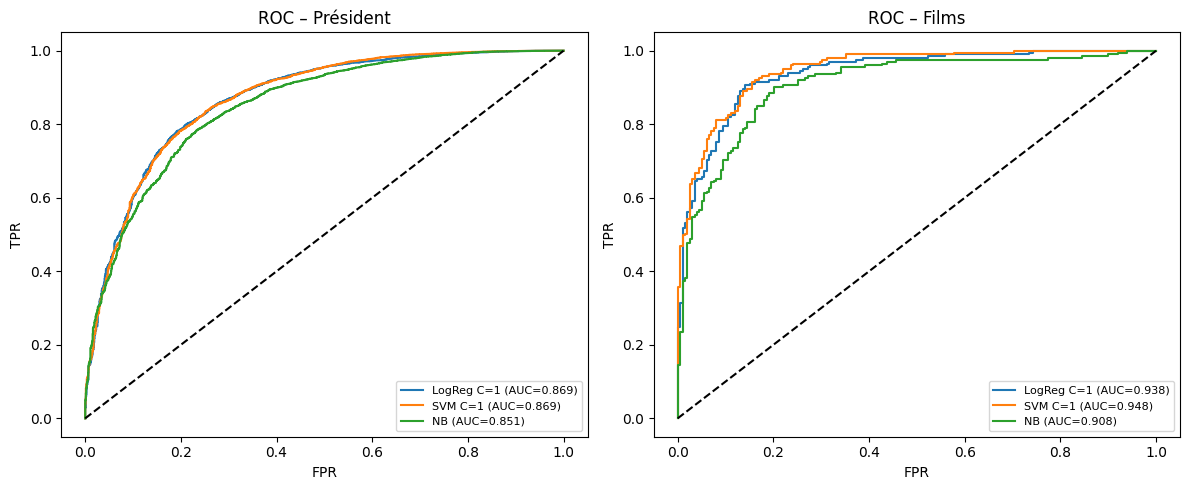

In [11]:
#  C.1) COMPARAISON DES CLASSIFIEURS 

# Je compare 3 familles de classifieurs vus en cours :
# Régression Logistique : modèle linéaire avec régularisation L2 (paramètre C)
#  SVM linéaire : maximise la marge entre les deux classes
# -Naive Bayes  : modèle probabiliste, rapide, bon sur texte déséquilibré
# J'évalue avec accuracy, F1 et AUC pour avoir une vision complète des performances

# Vectorisation TF-IDF bigrammes (meilleure variante vue en B)
vec_pres = TfidfVectorizer(max_features=10000, sublinear_tf=True, ngram_range=(1,2))
X_tr_pres = vec_pres.fit_transform(X_tr_p)
X_te_pres = vec_pres.transform(X_te_p)

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    txts_movies_pp, alllabs_movies, test_size=0.2, random_state=42)
vec_movies = TfidfVectorizer(max_features=10000, sublinear_tf=True, ngram_range=(1,2))
X_tr_mov = vec_movies.fit_transform(X_tr_m)
X_te_mov = vec_movies.transform(X_te_m)

classifieurs = {
    "LogReg C=0.1" : LogisticRegression(max_iter=1000, C=0.1),
    "LogReg C=1.0" : LogisticRegression(max_iter=1000, C=1.0),
    "LogReg C=10"  : LogisticRegression(max_iter=1000, C=10),
    "SVM C=0.1"    : CalibratedClassifierCV(LinearSVC(C=0.1, max_iter=2000)),
    "SVM C=1.0"    : CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)),
    "Naive Bayes"  : ComplementNB(),
}

for nom_tache, Xtr, Xte, ytr, yte in [
    ("Président", X_tr_pres, X_te_pres, y_tr_p, y_te_p),
    ("Films",     X_tr_mov,  X_te_mov,  y_tr_m, y_te_m),
]:
    print(f"\n=== {nom_tache} ===")
    print(f"{'Classifieur':<15} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
    print("-" * 50)
    for nom, clf in classifieurs.items():
        clf.fit(Xtr, ytr)
        pred  = clf.predict(Xte)
        proba = clf.predict_proba(Xte)[:, 1]
        print(f"{nom:<15} {accuracy_score(yte,pred):>10.4f} "
              f"{f1_score(yte,pred):>10.4f} {roc_auc_score(yte,proba):>10.4f}")

# Courbes ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nom_t, Xtr, Xte, ytr, yte) in zip(axes, [
    ("Président", X_tr_pres, X_te_pres, y_tr_p, y_te_p),
    ("Films",     X_tr_mov,  X_te_mov,  y_tr_m, y_te_m),
]):
    for nom, clf in {"LogReg C=1":LogisticRegression(max_iter=1000,C=1.0),
                     "SVM C=1"   :CalibratedClassifierCV(LinearSVC(C=1.0,max_iter=2000)),
                     "NB"        :ComplementNB()}.items():
        clf.fit(Xtr, ytr)
        fpr, tpr, _ = roc_curve(yte, clf.predict_proba(Xte)[:,1])
        ax.plot(fpr, tpr, label=f"{nom} (AUC={roc_auc_score(yte,clf.predict_proba(Xte)[:,1]):.3f})")
    ax.plot([0,1],[0,1],'k--'); ax.set_title(f"ROC – {nom_t}")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2) Variantes sur les stratégies d'entraînement

- **Sur-apprentissage**. Les techniques sur lesquelles nous travaillons étant sujettes au sur-apprentissage: trouver le paramètre de régularisation dans la documentation et optimiser ce paramètre au sens de la métrique qui vous semble la plus appropriée (cf question précédente).

 <br>
- **Equilibrage des données**. Un problème reconnu comme dur dans la communauté est celui de l'équilibrage des classes (*balance* en anglais). Que faire si les données sont à 80, 90 ou 99% dans une des classes?
Le problème est dur mais fréquent; les solutions sont multiples mais on peut isoler 3 grandes familles de solution.

1. Ré-équilibrer le jeu de données: supprimer des données dans la classe majoritaire et/ou sur-échantilloner la classe minoritaire.<BR>
   $\Rightarrow$ A vous de jouer pour cette technique
1. Changer la formulation de la fonction de coût pour pénaliser plus les erreurs dans la classe minoritaire:  
soit une fonction $\Delta$ mesurant les écarts entre $f(x_i)$ et $y_i$  
$$C = \sum_i  \alpha_i \Delta(f(x_i),y_i), \qquad \alpha_i = \left\{
\begin{array}{ll}
1 & \text{si } y_i \in \text{classe majoritaire}\\
B>1 & \text{si } y_i \in \text{classe minoritaire}\\
\end{array} \right.$$
<BR>
   $\Rightarrow$ Les SVM et d'autres approches sklearn possèdent des arguments pour régler $B$ ou $1/B$... Ces arguments sont utiles mais pas toujours suffisant.
1. Courbe ROC et modification du biais. Une fois la fonction $\hat y = f(x)$ apprise, il est possible de la *bidouiller* a posteriori: si toutes les prédictions $\hat y$ sont dans une classe, on va introduire $b$ dans $\hat y = f(x) + b$ et le faire varier jusqu'à ce qu'un des points change de classe. On peut ensuite aller de plus en plus loin.
Le calcul de l'ensemble des scores associés à cette approche mène directement à la courbe ROC.

**Note:** certains classifieurs sont intrinsèquement plus résistante au problème d'équilibrage, c'est par exemple le cas des techniques de gradient boosting que vous verrez l'an prochain.

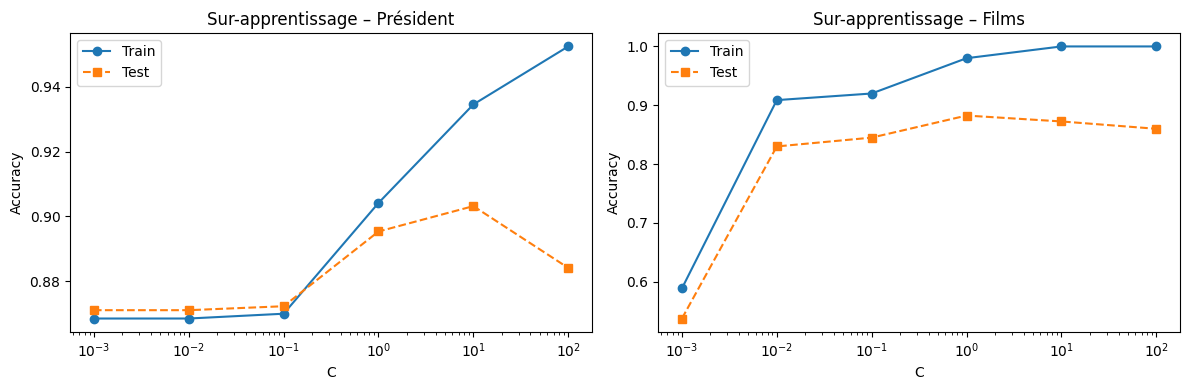

C trop grand → sur-apprentissage | C trop petit → sous-apprentissage


In [12]:
#  C.2) SUR-APPRENTISSAGE : impact du paramètre C 

# C est l'inverse du paramètre de régularisation : grand C = moins de régularisation.
# Je fais varier C de 0.001 à 100 pour trouver le compromis biais/variance optimal.
# Si l'écart train/test est grand → sur-apprentissage, le modèle mémorise sans généraliser.

C_vals = [0.001, 0.01, 0.1, 1, 10, 100]
res = {}
for nom_t, Xtr, Xte, ytr, yte in [
    ("Président", X_tr_pres, X_te_pres, y_tr_p, y_te_p),
    ("Films",     X_tr_mov,  X_te_mov,  y_tr_m, y_te_m),
]:
    tr_acc, te_acc = [], []
    for C in C_vals:
        clf = LogisticRegression(max_iter=2000, C=C)
        clf.fit(Xtr, ytr)
        tr_acc.append(accuracy_score(ytr, clf.predict(Xtr)))
        te_acc.append(accuracy_score(yte, clf.predict(Xte)))
    res[nom_t] = (tr_acc, te_acc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nom_t, (tr, te)) in zip(axes, res.items()):
    ax.semilogx(C_vals, tr, 'o-', label="Train")
    ax.semilogx(C_vals, te, 's--', label="Test")
    ax.set_xlabel("C"); ax.set_ylabel("Accuracy")
    ax.set_title(f"Sur-apprentissage – {nom_t}")
    ax.legend()
plt.tight_layout(); plt.show()
print("C trop grand → sur-apprentissage | C trop petit → sous-apprentissage")

In [13]:
#  C.2  ÉQUILIBRAGE DES DONNÉES – Tâche Président 
# Le corpus Président est très déséquilibré : Chirac représente ~87% des données,
# Mitterrand seulement ~13%. Sans correction, le modèle favorise la classe majoritaire.
# Solution : class_weight='balanced' → sklearn pénalise automatiquement les erreurs
# sur la classe minoritaire (Mitterrand) proportionnellement à son sous-représentation.
# On observe qu'avec l'équilibrage, l'accuracy globale baisse légèrement car le modèle
# fait plus d'erreurs sur Chirac, mais il détecte mieux les phrases de Mitterrand.

print(f"Chirac    : {alllabs.count(1)} ({alllabs.count(1)/len(alllabs)*100:.1f}%)")
print(f"Mitterrand: {alllabs.count(-1)} ({alllabs.count(-1)/len(alllabs)*100:.1f}%)")

# Sans équilibrage
clf_no_bal = LogisticRegression(max_iter=1000, C=1.0)
clf_no_bal.fit(X_tr_pres, y_tr_p)
pred_no_bal = clf_no_bal.predict(X_te_pres)

# Avec class_weight='balanced' (pénalise plus les erreurs sur Mitterrand)
clf_bal = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
clf_bal.fit(X_tr_pres, y_tr_p)
pred_bal = clf_bal.predict(X_te_pres)

print(f"\nSans équilibrage  → Accuracy={accuracy_score(y_te_p, pred_no_bal):.4f}, F1={f1_score(y_te_p, pred_no_bal):.4f}")
print(f"Avec class_weight → Accuracy={accuracy_score(y_te_p, pred_bal):.4f}, F1={f1_score(y_te_p, pred_bal):.4f}")

Chirac    : 49890 (86.9%)
Mitterrand: 7523 (13.1%)

Sans équilibrage  → Accuracy=0.8953, F1=0.9428
Avec class_weight → Accuracy=0.8297, F1=0.8962


## 3) Post-processing sur les données Président

Pour la tâche de reconnaissance de locuteur, des phrases successives sont souvent associés à un même locuteur. Voir par exemples les 100 premiers labels de la base d'apprentissage.

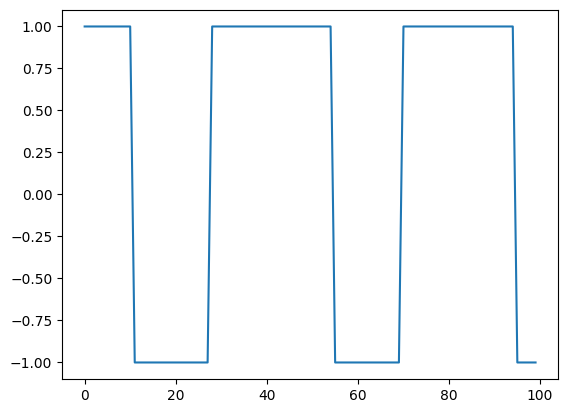

In [14]:
fname = "./datasets/AFDpresidentutf8/corpus.tache1.learn.utf8"
alltxts,alllabs = load_pres(fname)

plt.figure()
plt.plot(list(range(len(alllabs[0:100]))),alllabs[0:100])

**Une méthode de post-traitement pour améliorer les résultats consistent à lisser les résultats de la prédictions d'une phrases par les prédictions voisines, en utilisant par exemple une convolution par une filtre Gaussien. Compléter la fonction ci-dessous et tester l'impact de ce lissage sur les performances.**

In [15]:
def gaussian_smoothing(pred, sigma):
    """Lisse une séquence de prédictions avec un filtre Gaussien de largeur sigma.
    Les phrases voisines (même locuteur probable) influencent la prédiction courante.
    """
    return gaussian_filter1d(np.array(pred, dtype=float), sigma=sigma)

# L'idée : dans le corpus présidentiel, les phrases successives viennent souvent
# du même locuteur (on voit des blocs dans le graphe des labels).
# Donc si mes voisins sont classés Chirac, je devrais probablement l'être aussi.
# Le filtre gaussien lisse les probabilités avec les phrases voisines pondérées
# par une courbe en cloche (les plus proches ont plus de poids).

# Test : entraîner sur tout le corpus et évaluer l'impact du lissage
vec_gaus  = TfidfVectorizer(max_features=10000, sublinear_tf=True, ngram_range=(1,2))
X_all     = vec_gaus.fit_transform(txts_pres_pp)
clf_gaus  = LogisticRegression(max_iter=1000, C=1.0)
clf_gaus.fit(X_all, alllabs)

# P(Mitterrand) : p>0.5 → Mitterrand, p<0.5 → Chirac
mitt_idx   = list(clf_gaus.classes_).index(-1)
proba_mitt = clf_gaus.predict_proba(X_all)[:, mitt_idx]
y_true     = np.array(alllabs)

print(f"{'Sigma':<8} {'Accuracy':>10}")
print("-" * 20)
for sigma in [0, 1, 2, 5, 10, 20]:
    if sigma == 0:
        preds = (proba_mitt > 0.5).astype(int) * (-2) + 1  # >0.5 → -1, <0.5 → +1
    else:
        smoothed = gaussian_smoothing(proba_mitt, sigma)
        preds    = (smoothed > 0.5).astype(int) * (-2) + 1
    print(f"{sigma:<8} {accuracy_score(y_true, preds):>10.4f}")

Sigma      Accuracy
--------------------
0            0.9064
1            0.9001
2            0.8904
5            0.8743
10           0.8690
20           0.8690



## 4) Estimer les performances de généralisation d'une méthodes
**Ce sera l'enjeu principal du projet : vous disposez d'un ensemble de données, et vous évaluerez les performances sur un ensemble de test auquel vous n'avez pas accès. Il faut donc être capable d'estimer les performances de généralisation du modèles à partir des données d'entraînement.**


Avant de lancer de grandes expériences, il faut se construire une base de travail solide en étudiant les questions suivantes:

- Combien de temps ça prend d'apprendre un classifieur NB/SVM/RegLog sur ces données en fonction de la taille du vocabulaire?
- La validation croisée est-elle nécessaire? Est ce qu'on obtient les mêmes résultats avec un simple *split*?
- La validation croisée est-elle stable? A partir de combien de fold (travailler avec différentes graines aléatoires et faire des statistiques basiques)?

In [16]:
import time



# Question 1 : temps d'entraînement selon la taille du vocabulaire ──
print("=== Temps d'entraînement (Président) ===")
for max_f in [500, 1000, 5000, 10000, 50000]:
    vec_t = TfidfVectorizer(max_features=max_f, sublinear_tf=True)
    X_t = vec_t.fit_transform(txts_pres_pp)
    for nom_clf, clf in [("LogReg", LogisticRegression(max_iter=1000)),
                          ("SVM",    LinearSVC(max_iter=2000)),
                          ("NB",     ComplementNB())]:
        t0 = time.time()
        clf.fit(X_t, alllabs)
        print(f"  max_features={max_f:<6} {nom_clf:<7} → {time.time()-t0:.3f}s")

# Question 2 : val. croisée vs simple split ──
print("\n=== CV 5-fold vs simple split (Président, C=1) ===")
clf_q2 = LogisticRegression(max_iter=1000, C=1.0)
scores_cv = cross_val_score(clf_q2, X_all, alllabs, cv=5, scoring='accuracy')
print(f"  CV 5-fold  : {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")
for seed in [0, 1, 42, 123, 999]:
    Xtr, Xte, ytr, yte = train_test_split(X_all, alllabs, test_size=0.2, random_state=seed)
    clf_q2.fit(Xtr, ytr)
    print(f"  Split seed={seed:<4}: {accuracy_score(yte, clf_q2.predict(Xte)):.4f}")

# Question 3 : stabilité selon le nombre de folds ──
print("\n=== Stabilité selon le nombre de folds (Président, C=1) ===")
for n_fold in [3, 5, 10]:
    scores = cross_val_score(LogisticRegression(max_iter=1000, C=1.0),
                             X_all, alllabs,
                             cv=StratifiedKFold(n_fold, shuffle=True, random_state=42),
                             scoring='accuracy')
    print(f"  {n_fold}-fold : {scores.mean():.4f} ± {scores.std():.4f}")
print("\nConclusion : plus le nombre de folds est grand, plus l'estimation est stable (variance plus faible).")

=== Temps d'entraînement (Président) ===
  max_features=500    LogReg  → 0.034s
  max_features=500    SVM     → 0.072s
  max_features=500    NB      → 0.003s
  max_features=1000   LogReg  → 0.036s
  max_features=1000   SVM     → 0.076s
  max_features=1000   NB      → 0.003s
  max_features=5000   LogReg  → 0.059s
  max_features=5000   SVM     → 0.079s
  max_features=5000   NB      → 0.004s
  max_features=10000  LogReg  → 0.071s
  max_features=10000  SVM     → 0.088s
  max_features=10000  NB      → 0.004s
  max_features=50000  LogReg  → 0.068s
  max_features=50000  SVM     → 0.089s
  max_features=50000  NB      → 0.004s

=== CV 5-fold vs simple split (Président, C=1) ===
  CV 5-fold  : 0.8921 ± 0.0011
  Split seed=0   : 0.8945
  Split seed=1   : 0.8898
  Split seed=42  : 0.8961
  Split seed=123 : 0.8939
  Split seed=999 : 0.8899

=== Stabilité selon le nombre de folds (Président, C=1) ===
  3-fold : 0.8923 ± 0.0013
  5-fold : 0.8936 ± 0.0013
  10-fold : 0.8949 ± 0.0022

Conclusion : plus

In [17]:
#  C.4) VALIDATION CROISÉE 


# Problème du simple split : selon la graine aléatoire, les résultats varient.
# La validation croisée à 5 folds découpe les données en 5 parties,
# entraîne sur 4 et teste sur 1, et répète 5 fois.
# On obtient une estimation plus stable avec un intervalle de confiance (moyenne ± écart-type).
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Validation croisée 5-fold – Tâche Président ===")
for C in [0.1, 1.0, 10.0]:
    scores = cross_val_score(
        LogisticRegression(max_iter=1000, C=C), X_all, alllabs, cv=cv, scoring='accuracy')
    print(f"  C={C:<5} | Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

vec_cv_m = TfidfVectorizer(max_features=10000, sublinear_tf=True, ngram_range=(1,2))
X_all_mov = vec_cv_m.fit_transform(txts_movies_pp)

print("\n=== Validation croisée 5-fold – Tâche Films ===")
for C in [0.1, 1.0, 10.0]:
    scores = cross_val_score(
        LogisticRegression(max_iter=1000, C=C), X_all_mov, alllabs_movies, cv=cv, scoring='accuracy')
    print(f"  C={C:<5} | Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

print("\nLa val. croisée est plus fiable qu'un simple split (moins de variance).")

=== Validation croisée 5-fold – Tâche Président ===
  C=0.1   | Accuracy: 0.8702 ± 0.0004
  C=1.0   | Accuracy: 0.8936 ± 0.0013
  C=10.0  | Accuracy: 0.8985 ± 0.0029

=== Validation croisée 5-fold – Tâche Films ===
  C=0.1   | Accuracy: 0.8260 ± 0.0166
  C=1.0   | Accuracy: 0.8545 ± 0.0130
  C=10.0  | Accuracy: 0.8735 ± 0.0097

La val. croisée est plus fiable qu'un simple split (moins de variance).


## Génération des fichiers CSV de soumission (jusqu'à 7 par tâche)

In [18]:
#  GÉNÉRATION DES CSV DE SOUMISSION 
# FORMAT PRÉSIDENT : P(Chirac) par ligne
#   → P < 0.5 = Chirac, P > 0.5 = Mitterrand (convention prof)
# FORMAT FILMS     : P (positif) ou N (négatif) par ligne


os.makedirs("./rital_tmp", exist_ok=True)


# FONCTIONS UTILITAIRES


def predict_chirac_proba(clf, vec, txts_train, labs_train, txts_test, sigma=0):
    """Entraîne le modèle et retourne P(Chirac) sur le jeu de test.
    Convention : P(Chirac) < 0.5 → Chirac, P(Chirac) > 0.5 → Mitterrand
    """
    X_train = vec.fit_transform(txts_train)
    X_test  = vec.transform(txts_test)
    clf.fit(X_train, labs_train)
    chirac_idx = list(clf.classes_).index(1)   # label Chirac = +1
    p_chirac   = clf.predict_proba(X_test)[:, chirac_idx]
    if sigma > 0:
        p_chirac = gaussian_smoothing(p_chirac, sigma)
    return p_chirac

def predict_movie_labels(clf, vec, txts_train, labs_train, txts_test):
    """Entraîne le modèle et retourne P/N sur le jeu de test."""
    X_train = vec.fit_transform(txts_train)
    X_test  = vec.transform(txts_test)
    clf.fit(X_train, labs_train)
    preds = clf.predict(X_test)
    return ['P' if p == 1 else 'N' for p in preds]

def save_csv(data, filepath):
    with open(filepath, "w") as f:
        for val in data:
            f.write(f"{val}\n")


# 7 SOUMISSIONS – TÂCHE PRÉSIDENT

# Configurations : (n, clf, sigma)
# On entraîne sur txts_pres_pp (train) et prédit sur txts_test_pres_pp (test)

configs_pres = [
    # n  clf                                          sigma
    (1,  LogisticRegression(max_iter=1000, C=1.0),    0),   # LogReg C=1, sans lissage
    (2,  LogisticRegression(max_iter=1000, C=1.0),    5),   # LogReg C=1, avec lissage σ=5
    (3,  LogisticRegression(max_iter=1000, C=10.0),   0),   # LogReg C=10, sans lissage
    (4,  LogisticRegression(max_iter=1000, C=10.0),   5),   # LogReg C=10, avec lissage σ=5
    (5,  CalibratedClassifierCV(LinearSVC(C=0.1, max_iter=2000)), 0),  # SVM C=0.1
    (6,  CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)), 0),  # SVM C=1.0
    (7,  CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)), 5),  # SVM C=1.0 + lissage
]

print("=== Soumissions Président ===")
for n, clf, sigma in configs_pres:
    vec = TfidfVectorizer(max_features=10000, sublinear_tf=True, ngram_range=(1,2))
    p_chirac = predict_chirac_proba(clf, vec,
                                    txts_pres_pp, alllabs,
                                    txts_test_pres_pp, sigma)
    fpath = f"./rital_tmp/submission-pres-{n}.csv"
    save_csv(p_chirac, fpath)
    chirac_count = sum(1 for p in p_chirac if p < 0.5)
    mitt_count   = len(p_chirac) - chirac_count
    print(f"  submission-pres-{n}.csv → {len(p_chirac)} lignes "
          f"| Chirac={chirac_count}, Mitterrand={mitt_count} "
          f"| sigma={sigma}")


# 7 SOUMISSIONS – TÂCHE FILMS


configs_movies = [
    # m  clf
    (1,  LogisticRegression(max_iter=1000, C=1.0)),
    (2,  LogisticRegression(max_iter=1000, C=0.1)),
    (3,  LogisticRegression(max_iter=1000, C=10.0)),
    (4,  CalibratedClassifierCV(LinearSVC(C=0.1, max_iter=2000))),
    (5,  CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000))),
    (6,  CalibratedClassifierCV(LinearSVC(C=10.0, max_iter=2000))),
    (7,  ComplementNB()),
]

print("\n=== Soumissions Films ===")
for m, clf in configs_movies:
    vec = TfidfVectorizer(max_features=10000, sublinear_tf=True, ngram_range=(1,2))
    preds = predict_movie_labels(clf, vec,
                                 txts_movies_pp, alllabs_movies,
                                 txts_test_mov_pp)
    fpath = f"./rital_tmp/submission-movie-{m}.csv"
    save_csv(preds, fpath)
    pos_count = preds.count('P')
    neg_count = preds.count('N')
    print(f"  submission-movie-{m}.csv → {len(preds)} lignes "
          f"| P={pos_count}, N={neg_count}")


# VÉRIFICATION FINALE

print("\n── Vérification des fichiers générés ──")
for fname_csv in sorted(os.listdir('./rital_tmp')):
    if not fname_csv.endswith('.csv'):
        continue
    fpath = f'./rital_tmp/{fname_csv}'
    with open(fpath) as fh:
        lignes = fh.readlines()
    premier = lignes[0].strip()
    print(f"  {fname_csv:<30} {len(lignes):>6} lignes | ex: {premier}")

print("\n✓ Tous les fichiers CSV sont prêts dans rital_tmp/")
print("  → git add rital_tmp/ && git commit -m 'ajout soumissions CSV' && git push")


=== Soumissions Président ===
  submission-pres-1.csv → 27162 lignes | Chirac=1241, Mitterrand=25921 | sigma=0
  submission-pres-2.csv → 27162 lignes | Chirac=39, Mitterrand=27123 | sigma=5
  submission-pres-3.csv → 27162 lignes | Chirac=2313, Mitterrand=24849 | sigma=0
  submission-pres-4.csv → 27162 lignes | Chirac=538, Mitterrand=26624 | sigma=5
  submission-pres-5.csv → 27162 lignes | Chirac=1754, Mitterrand=25408 | sigma=0
  submission-pres-6.csv → 27162 lignes | Chirac=1515, Mitterrand=25647 | sigma=0
  submission-pres-7.csv → 27162 lignes | Chirac=126, Mitterrand=27036 | sigma=5

=== Soumissions Films ===
  submission-movie-1.csv → 25000 lignes | P=11035, N=13965
  submission-movie-2.csv → 25000 lignes | P=10273, N=14727
  submission-movie-3.csv → 25000 lignes | P=11508, N=13492
  submission-movie-4.csv → 25000 lignes | P=10974, N=14026
  submission-movie-5.csv → 25000 lignes | P=11552, N=13448
  submission-movie-6.csv → 25000 lignes | P=11691, N=13309
  submission-movie-7.csv →